# <h1><center>Lógica Computacional 2024/2025 - TP1</center></h1>

 **Grupo 6**
 * Cláudia Faria, a105531
 * Patrícia Bastos, a102502

In [ ]:
!pip install pysmt
!pysmt-install --z3
!pip install ortools
!pip install networkx

In [10]:
import networkx as nx

import random
from ortools.linear_solver import pywraplp

## **Exercício 2**

### Enunciado



  Um sistema de tráfego é representado por um grafo orientado ligado. Os nodos denotam pontos de acesso e  os arcos denotam vias de comunicação só com um sentido .  O grafo tem de ser ligado: entre cada par de nodos $\langle n_1,n_2 \rangle$ tem de existir um caminho $n_1 \leadsto n_2$ e um caminho $n_2\leadsto n_1$.

  1. Gerar aleatoriamente o grafo com  $N \in\{6..10\}$  nodos e com ramos verificando:
      1. Cada nodo tem um número aleatório de descendentes $d\in\{1 .. 3\}\,$ cujos destinos são também gerados aleatoriamente.
      2. Se  existirem “loops” ou destinos repetidos, deve-se gerar outro grafo.
      
  2. Pretende-se fazer  manutenção interrompendo  determinadas vias. Determinar o maior número de vias que é possível remover mantendo o grafo ligado.

### Variáveis

**Inputs**

* $grafo$ - grafo gerado pelo programa
* $N∈[6..10]$ - número de nodos gerado aleatoriamente

**Auxiliares**

* **Geração do grafo**
  * $n\_descende$ - número de descendentes gerado aleatoriamente
  * $possiveis$ - lista de nodos aos quais um nodo se pode ligar (todos exceto o próprio)
  * $descendentes$ - nodos escolhidos aleatoriamente como descendentes

* **Manutenção das vias**
  * $arestas[aresta]$ - indica se a aresta foi apagada
  * $lista\_caminhos[nodo1, nodo2]$ - lista de todos os caminhos de $nodo1$ a $nodo2$ expressa pelas arestas
  * $caminho[nodo1, nodo2, i]$ - indica se o i-ésimo caminho do $nodo1$ ao $nodo2$ foi apagado


### Restrições


*   Nodos denotam pontos de acesso
*   Arcos denotam vias de comunicação só com um sentido
*   Entre cada par de nodos $<n1,n2>$ tem de existir um caminho de $n1$ para $n2$ e de $n2$ para $n1$

*   Cada nodo tem um número aleatório de descendentes $(1..3)$
*   Caso existam loops ou destinos repetidos deve-se gerar outro grafo
*   Determinar o maior número de vias que é possível remover mantendo o grafo ligado.



### Geração do grafo

Queremos gerar um grafo ligado, com 6 a 10 nodos, sendo que cada nodo tem um número aleatório de descendentes entre 1 e 3, cujos destinos são gerados aleatoriamente. Não queremos que o grafo contenha loops ou destinos repetidos.

Vamos então gerar um número inteiro N aleatoriamente entre 6 e 10. Este será o número de nodos do nosso grafo. Criamos um grafo direcionado e adicionamos N nodos.
Para cada nodo do grafo, é gerado um número n_descende aleatório entre 1 e 3. Criamos uma lista possiveis de nodos possíveis aos quais o nodo se pode ligar, excluindo o próprio nodo. Escolhemos n_descende nodos da lista possiveis, obtendo 1 a 3 destinos aleatórios. Adicionamos então estas arestas ao nodo. Este processo é repetido para cada nodo.

No final, verificamos se o grafo é ligado e planar. Caso não seja, gera-se outro grafo.

{1: [4],
 2: [1],
 3: [2, 1, 7],
 4: [8],
 5: [6, 4, 1],
 6: [1, 3, 7],
 7: [5, 6, 4],
 8: [4, 3, 2]}

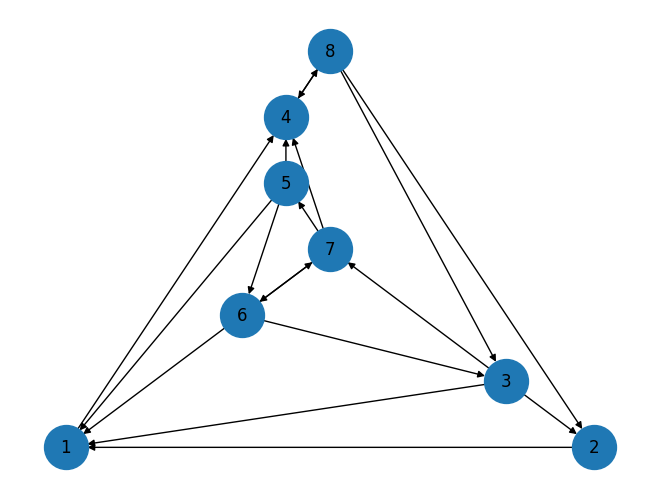

In [11]:
correto = False

while correto == False:

  N = random.choice(range(6, 11))
  grafo = nx.DiGraph()
  grafo.add_nodes_from(range(1, N+1))

  for nodo in grafo.nodes():
    n_descende = random.choice(range(1, 4))  # número de descendentes
    possiveis = list(grafo.nodes()) # nodos a quais pode ligar
    possiveis.remove(nodo)
    descendentes = random.sample(possiveis, n_descende)
    # escolhe aleatoriamente os nodos

    for desc in descendentes:
      grafo.add_edge(nodo, desc) # cria a aresta

  if nx.is_strongly_connected(grafo) and nx.is_planar(grafo):
    # verifica se está correto
    correto = True
  else:
    grafo.clear()

nx.draw(grafo,pos=nx.planar_layout(grafo),with_labels=True,node_size=1000)
nx.to_dict_of_lists(grafo)

### Manutenção das vias

Primeiro, é criada uma variável arestas para cada aresta. O valor desta variável é 0 se for apagada ou 1 se não for apagada.

Criamos uma lista lista_caminhos para cada nodo1 e nodo2 dos nodos do grafo, que contém todos os caminhos simples do nodo1 ao nodo2 expressos em listas de arestas.

Para cada caminho, é criada uma variável caminho que é 0 se o caminho não existe no grafo solução, ou 1 se existe.

Então, para cada aresta de cada caminho, é adicionada a seguinte restrição:

*   Se a aresta é apagada, o caminho não existe.
*   Se a aresta não é apagada, o caminho pode ou não existir (estando dependente da existência das restantes arestas no grafo solução).



Acrescenta-se ainda a restrição de que, para cada nodo1 e nodo2, tem de haver um caminho de nodo1 para nodo2.

Por último minimizamos a soma de arestas para cada aresta do grafo, ou seja, o valor desta soma será o menor possível, resultando no máximo de vias apagadas.

####Inicialização do Solver

In [12]:
solver = pywraplp.Solver.CreateSolver("SCIP")

print("Grafo: ", nx.to_dict_of_lists(grafo))
print("\nArestas:", grafo.edges)


Grafo:  {1: [4], 2: [1], 3: [2, 1, 7], 4: [8], 5: [6, 4, 1], 6: [1, 3, 7], 7: [5, 6, 4], 8: [4, 3, 2]}

Arestas: [(1, 4), (2, 1), (3, 2), (3, 1), (3, 7), (4, 8), (5, 6), (5, 4), (5, 1), (6, 1), (6, 3), (6, 7), (7, 5), (7, 6), (7, 4), (8, 4), (8, 3), (8, 2)]


#### Adição das restrições do problema

In [13]:
arestas = {}
for aresta in grafo.edges:
  arestas[aresta] = solver.IntVar(0, 1, f"arestas[{aresta}]")
  # variável arestas[aresta] é criada para cada aresta
  # arestas[aresta] é 0 se a aresta é apagada, 1 se permanecer

caminho = {}
for nodo1 in grafo.nodes:
  for nodo2 in grafo.nodes:
    if nodo1 != nodo2:

      lista_caminhos = list(nx.all_simple_edge_paths(grafo, source = nodo1, target = nodo2))
      # lista de todos os caminhos de qualquer nodo1 a qualquer nodo2 (diferentes)

      for i in range(len(lista_caminhos)): # i-ésimo caminho
        caminho[(nodo1, nodo2, i)] = solver.IntVar(0, 1, f"caminho[{(nodo1, nodo2, i)}]")
        # variável caminho[(nodo1, nodo2, i)] é 0 se o caminho não existe, 1 se existe

        for aresta in lista_caminhos[i]: # para cada aresta no i-ésimo caminho,
          solver.Add(caminho[(nodo1, nodo2, i)] <= arestas[aresta])
          # se arestas[aresta] = 0: caminho[(nodo1, nodo2, i)] = 0
              # ou seja, se a aresta é apagada, o caminho não existe
          # se arestas[aresta] = 1: caminho[(nodo1, nodo2, i)] = 1 ou 0
              # ou seja, se a aresta não é apagada, pode ou não existir
              # (dependendo das outras arestas)

      solver.Add(sum([caminho[(nodo1, nodo2, i)] for i in range(len(lista_caminhos))]) >= 1)
      # a soma de todos os caminhos do nodo1 ao nodo2 tem de ser maior que 1,
      # ou seja, tem de existir pelo menos 1 caminho

#### Definição do objetivo do problema

De forma a maximizar o número de arestas apagadas é usado o $solver.Minimize$, minimizando a soma de $arestas[aresta]$, que é 0 quando a aresta foi apagada.

In [14]:
solver.Minimize(solver.Sum(arestas[aresta] for aresta in grafo.edges))

#### Procura da Solução através do solver e Interpretação dos resultados

Foi encontrada uma solução para o problema.

Via (3, 1) é removida.
Via (5, 4) é removida.
Via (5, 1) é removida.
Via (6, 1) é removida.
Via (6, 7) é removida.
Via (7, 6) é removida.
Via (7, 4) é removida.
Via (8, 4) é removida.
Via (8, 2) é removida.

Foram removidas 9 vias.


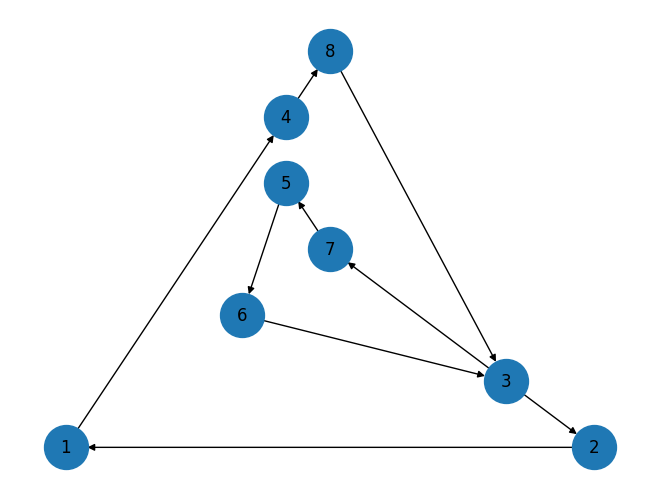

In [15]:

solucao2 = solver.Solve()
vias_removiveis = 0

if solucao2 == pywraplp.Solver.OPTIMAL:
  print("Foi encontrada uma solução para o problema.\n")
  for aresta in grafo.edges:
    if arestas[aresta].solution_value() == 0:
      print(f"Via {aresta} é removida.")
      vias_removiveis += 1
  print(f"\nForam removidas {vias_removiveis} vias.")
else:
  print("Não foi encontrada uma solução para o problema.")

subgrafo = nx.DiGraph()
for aresta in grafo.edges:
  if arestas[aresta].solution_value() == 1:
    subgrafo.add_edge(aresta[0], aresta[1])
nx.draw(subgrafo,pos=nx.planar_layout(grafo),with_labels=True,node_size=1000)